# Customer Churn Exploratory Data Analysis and Visualisation

By Hamza Khan

# Objectives of the Analysis

The primary objective of this Exploratory Data Analysis (EDA) is to gain insights from the Customer Churn Dataset. Through this analysis, we aim to:

- Understand the underlying structure and distribution of the data
- Identify trends, patterns, and anomalies that can inform further analysis
- Explore relationships between different variables to uncover potential correlations
- Visualize key metrics and insights to facilitate better decision-making
- Prepare the dataset for any subsequent predictive modeling or statistical analysis
- Train the model for prediction
- Test the model and evaluate it's accuracy 
  

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [12]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (6)\Churn_Modelling.csv")

In [41]:
df

,RowNumber,CustomerId,Exited,Surname_Abazu,Surname_Abbie,Surname_Abbott,Surname_Abdullah,Surname_Abdulov,Surname_Abel,Surname_Abernathy,...,EstimatedSalary_199805.63,EstimatedSalary_199808.1,EstimatedSalary_199841.32,EstimatedSalary_199857.47,EstimatedSalary_199862.75,EstimatedSalary_199909.32,EstimatedSalary_199929.17,EstimatedSalary_199953.33,EstimatedSalary_199970.74,EstimatedSalary_199992.48
0,1,15634602,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,15647311,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,15619304,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,15701354,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,15737888,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,9997,15569892,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,9998,15584532,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,9999,15682355,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape

(10000, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Checking for Null or Missing Values

In [27]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no Blank or Missing Values

In [38]:
df[df['Exited'] == 1].shape

2037

# Checking for Duplicate Values

In [13]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [18]:
df.duplicated().sum()

0

There are no Duplicated Values to be Deleted or Imputed

# Percentage of People Exited/Churned

In [48]:
(df[df['Exited'] == 1].shape[0]/df.shape[0]) * 100

20.369999999999997

In [61]:
churn = df['Exited'].value_counts().reset_index()
churn

,Exited,count
0,0,7963
1,1,2037


In [125]:
churn.rename(columns = {'Exited': 'Churn', 'count': 'Count'}, inplace = True)

# Plots

Text(0, 0.5, 'Total Churned')

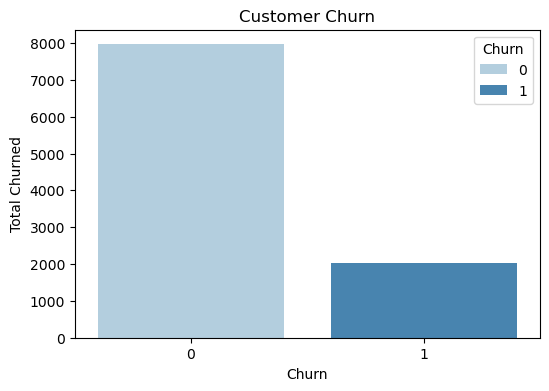

In [241]:
plt.figure(figsize=(6, 4))
sns.barplot(x = churn['Churn'], y = churn['Count'], hue= churn['Churn'], palette = 'Blues')
plt.title('Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Total Churned')

The Graph above suggests that the customers churned are alot lesser in percentage. Only 20%

Text(0.5, 0, 'Tenure in Years')

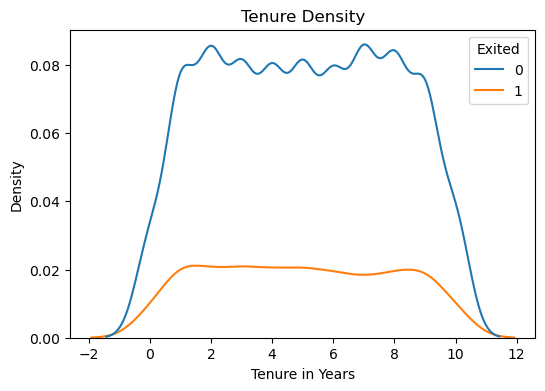

In [25]:
plt.figure(figsize=(6, 4))
sns.kdeplot(x=df['Tenure'], hue=df['Exited'])
plt.title('Tenure Density')
plt.xlabel('Tenure in Years')

The Graph above suggests that customers who have been with the company for a shorter period are more likely to churn, while those with longer tenures are more likely to stay. So one of the ways to reduce customer churning would be retain customers for longer tenure.








In [153]:
churned = df[df['Exited']== 1]

In [155]:
churned.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1


In [159]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

Text(0, 0.5, 'Total Churned')

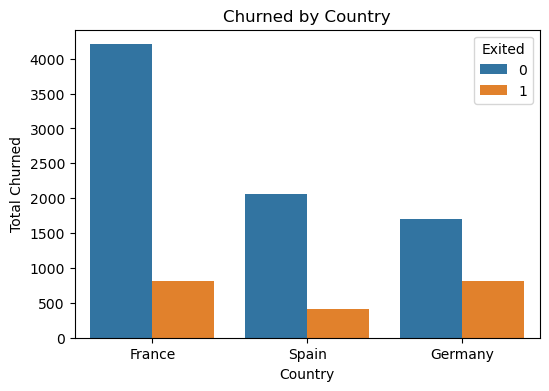

In [254]:
plt.figure(figsize = (6, 4))
sns.countplot(x=df['Geography'], hue=df['Exited'])
plt.title('Churned by Country')
plt.xlabel('Country')
plt.ylabel('Total Churned')

Text(0, 0.5, 'Total Churned')

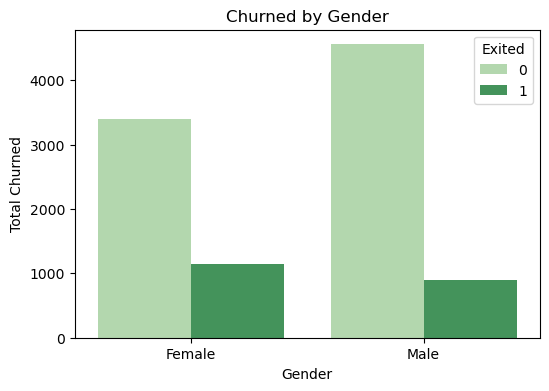

In [247]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['Gender'], hue = df['Exited'], palette = 'Greens')
plt.title('Churned by Gender')
plt.ylabel('Total Churned')

Text(0, 0.5, 'Total Churned')

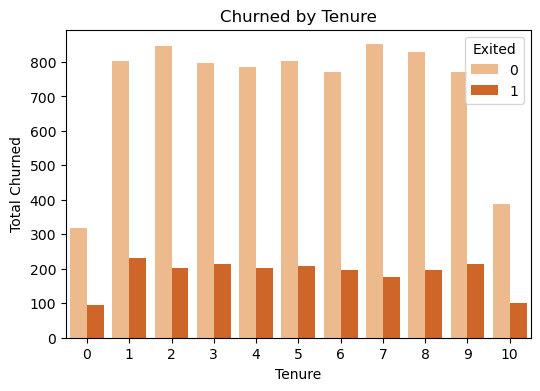

In [249]:
plt.figure(figsize = (6,4))
c_by_t = sns.countplot(x = df['Tenure'], hue = df['Exited'], palette = 'Oranges')
plt.title('Churned by Tenure')
plt.ylabel('Total Churned')

The Graph above shows that customers with 1 year tenure are more ikely to churn.

In [258]:
status = df['HasCrCard'].value_counts().reset_index()

In [260]:
status

,HasCrCard,count
0,1,7055
1,0,2945


In [262]:
status.rename(columns = {'HasCrCard': 'CreditCard', 'count': 'Count'})

,CreditCard,Count
0,1,7055
1,0,2945


Text(0, 0.5, 'Total Churned')

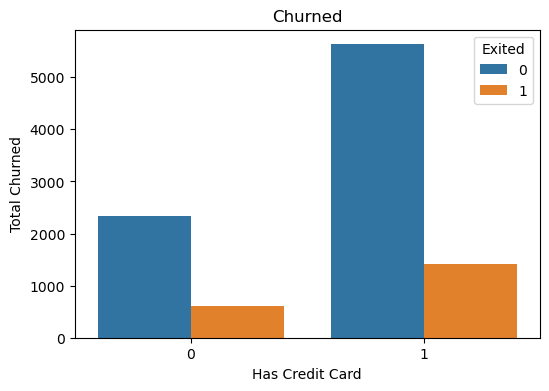

In [286]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['HasCrCard'], hue = df['Exited'])
plt.title('Churned')
plt.xlabel('Has Credit Card')
plt.ylabel('Total Churned')

The above Graph shows that the customers that have a Credit Card are more likely to churn.

Text(0, 0.5, 'Total Churned')

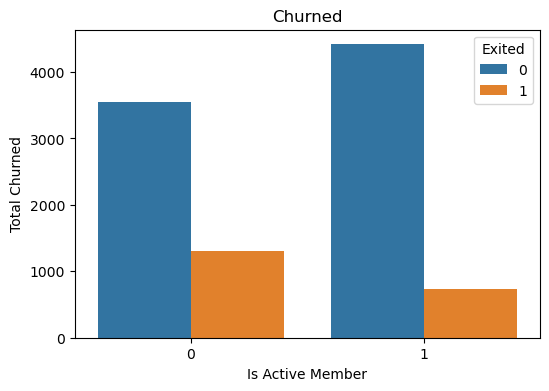

In [278]:
plt.figure(figsize = (6,4))
sns.countplot(x = df['IsActiveMember'], hue = df['Exited'], palette = (''))
plt.title('Churned')
plt.xlabel('Is Active Member')
plt.ylabel('Total Churned')

The graph above shows that customers who are not an active member are more likely to churn.

In [16]:
geography = df['Geography'].value_counts().reset_index()

In [18]:
geography

,Geography,count
0,France,5014
1,Germany,2509
2,Spain,2477


In [20]:
geography.rename(columns = {'Geography': 'Country', 'count': 'Count'}, inplace = True)

Text(0.5, 1.0, 'Customers Churned by Country')

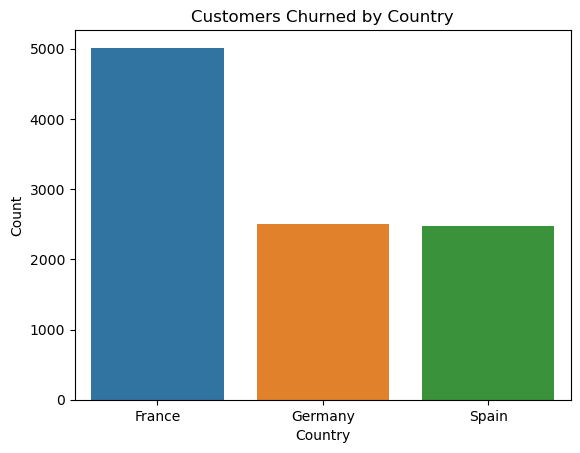

In [22]:
sns.barplot(x = geography['Country'], y = geography['Count'], hue = geography['Country'] )
plt.title('Customers Churned by Country')

The above Graph shows that the most people churned belonged to the country France.

In [ ]:
# Converting non

In [31]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [33]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [49]:
df.columns

Index(['RowNumber', 'CustomerId', 'Exited', 'Surname_Abazu', 'Surname_Abbie',
       'Surname_Abbott', 'Surname_Abdullah', 'Surname_Abdulov', 'Surname_Abel',
       'Surname_Abernathy',
       ...
       'EstimatedSalary_199805.63', 'EstimatedSalary_199808.1',
       'EstimatedSalary_199841.32', 'EstimatedSalary_199857.47',
       'EstimatedSalary_199862.75', 'EstimatedSalary_199909.32',
       'EstimatedSalary_199929.17', 'EstimatedSalary_199953.33',
       'EstimatedSalary_199970.74', 'EstimatedSalary_199992.48'],
      dtype='object', length=19870)

# One-hot Encoding

In [ ]:
df = pd.get_dummies(df, columns = ['Surname', 'Geography', 'Gender', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'])

In [ ]:
df.drop(columns = ['RowNumber', 'CustomerId'])

# Splitting the data into Features and Targets

In [52]:
x = df.drop(columns = 'Exited')
y = df['Exited']

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

# Training the Model

In [56]:
model = LogisticRegression()

In [57]:
train = model.fit(x_train, y_train)

# Testing the Model

In [61]:
test = model.predict(x_test)

In [97]:
accuracy_score(test, y_test)

0.7945

The accuracy of the model turns out to be 80% which is a well trained model.